## Publication Charts — Complete

Seven charts produced to consistent style standards.
All saved to `/outputs/charts/` with `p0X_` prefix.

| File | Content |
|---|---|
| p01_yield_curve_evolution | UK gilt yield curve and slope 2016–2026 |
| p02_annual_total_return | Total return decomposition by maturity 2016–2025 |
| p03_inflation_expectations | Breakeven inflation vs realised CPI |
| p04_transitory_threshold | Transitory narrative threshold analysis |
| p05_international_regression | International comparison and OLS residuals |
| p06_truss_event_study | Truss mini-budget event study and z-scores |
| p07_current_environment | Current yield curve vs historical context |

Style conventions: consistent colour palette, white background,
source notes on all charts, sized for GitHub rendering.


In [1]:
# ============================================================
# SETUP — WORKING DIRECTORY, IMPORTS, STYLE CONVENTIONS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import os

# Fix working directory
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

print(f"Working directory: {os.getcwd()}")

# ============================================================
# CONSISTENT COLOUR PALETTE — USED ACROSS ALL CHARTS
# ============================================================

COLORS = {
    # Gilt maturities
    'uk_2yr':   '#1565C0',  # Dark blue
    'uk_5yr':   '#1E88E5',  # Mid blue
    'uk_10yr':  '#42A5F5',  # Light blue
    'uk_30yr':  '#0D47A1',  # Navy

    # International
    'uk':       '#1565C0',  # Blue — UK
    'us':       '#C62828',  # Red — US
    'de':       '#2E7D32',  # Green — Germany

    # Inflation / real
    'nominal':  '#1565C0',  # Blue
    'real':     '#C62828',  # Red
    'breakeven':'#F57C00',  # Orange
    'cpi':      '#6A1B9A',  # Purple

    # Scenarios
    'soft':     '#2E7D32',  # Green
    'stagflat': '#C62828',  # Red
    'fiscal':   '#E65100',  # Dark orange

    # General
    'positive': '#2E7D32',  # Green
    'negative': '#C62828',  # Red
    'neutral':  '#9E9E9E',  # Grey
    'event':    '#424242',  # Dark grey for event lines
}

# ============================================================
# STYLE DEFAULTS — APPLIED TO ALL CHARTS
# ============================================================

plt.rcParams.update({
    'font.family':       'sans-serif',
    'font.size':         10,
    'axes.titlesize':    11,
    'axes.titleweight':  'bold',
    'axes.labelsize':    10,
    'xtick.labelsize':   9,
    'ytick.labelsize':   9,
    'legend.fontsize':   9,
    'figure.facecolor':  'white',
    'axes.facecolor':    'white',
    'axes.grid':         True,
    'grid.alpha':        0.3,
    'grid.linewidth':    0.5,
    'lines.linewidth':   1.4,
    'savefig.dpi':       150,
    'savefig.bbox':      'tight',
    'savefig.facecolor': 'white',
})

SOURCE_BOE   = 'Source: Bank of England Statistical Interactive Database.'
SOURCE_MULTI = 'Sources: Bank of England; Federal Reserve (FRED); ONS.'

print("Colour palette and style defaults set.")
print(f"\nColours defined: {list(COLORS.keys())}")

# ============================================================
# LOAD ALL DATA
# ============================================================

gilts_nominal   = pd.read_csv('data/processed/uk_gilts_nominal.csv',
                               index_col=0, parse_dates=True)
gilts_real      = pd.read_csv('data/processed/uk_gilts_real.csv',
                               index_col=0, parse_dates=True)
inflation_curve = pd.read_csv('data/processed/uk_inflation_curve.csv',
                               index_col=0, parse_dates=True)
us_treasuries   = pd.read_csv('data/processed/us_treasuries.csv',
                               index_col=0, parse_dates=True)
german_bund     = pd.read_csv('data/processed/german_bund.csv',
                               index_col=0, parse_dates=True)
cpi             = pd.read_csv('data/processed/ons_cpi.csv',
                               index_col=0, parse_dates=True)
macro           = pd.read_csv('data/processed/macro_variables.csv',
                               index_col=0, parse_dates=True)

# Fix index names
for df in [gilts_nominal, gilts_real, inflation_curve,
           us_treasuries, german_bund, cpi, macro]:
    df.index.name = 'date'

# Derived series
gilts_nominal['spread_2_10'] = (gilts_nominal['uk_10yr'] -
                                 gilts_nominal['uk_2yr'])
gilts_nominal['spread_5_30'] = (gilts_nominal['uk_30yr'] -
                                 gilts_nominal['uk_5yr'])

breakevens = pd.DataFrame({
    'be_5yr':   inflation_curve['uk_inf_5yr'],
    'be_10yr':  inflation_curve['uk_inf_10yr'],
    'be_30yr':  inflation_curve['uk_inf_30yr'],
    'real_10yr': gilts_real['uk_real_10yr'],
    'nom_10yr':  gilts_nominal['uk_10yr'],
}, index=inflation_curve.index)

breakevens['fwd_5y5y'] = (
    ((1 + breakevens['be_10yr'] / 100) ** 10 /
     (1 + breakevens['be_5yr']  / 100) ** 5) ** (1/5) - 1
) * 100

cpi_daily = cpi['cpi_yoy'].resample('D').ffill()

# Confirm
print(f"\nData loaded:")
for name, df in [('UK nominal gilts', gilts_nominal),
                 ('UK real gilts',    gilts_real),
                 ('Inflation curve',  inflation_curve),
                 ('US Treasuries',    us_treasuries),
                 ('German Bund',      german_bund),
                 ('CPI',              cpi),
                 ('Breakevens',       breakevens)]:
    print(f"  {name:<22} {df.shape[0]:>5} rows  "
          f"{df.index[0].date()} to {df.index[-1].date()}")

Working directory: C:\Users\tomsu\Documents\Graduate Jobs\CV PROJECTS\uk-gilt-market-analysis
Colour palette and style defaults set.

Colours defined: ['uk_2yr', 'uk_5yr', 'uk_10yr', 'uk_30yr', 'uk', 'us', 'de', 'nominal', 'real', 'breakeven', 'cpi', 'soft', 'stagflat', 'fiscal', 'positive', 'negative', 'neutral', 'event']

Data loaded:
  UK nominal gilts        2589 rows  2016-01-04 to 2026-03-31
  UK real gilts           2589 rows  2016-01-04 to 2026-03-31
  Inflation curve         2589 rows  2016-01-04 to 2026-03-31
  US Treasuries           2675 rows  2016-01-01 to 2026-04-02
  German Bund              121 rows  2016-01-01 to 2026-01-01
  CPI                      122 rows  2016-01-01 to 2026-02-01
  Breakevens              2589 rows  2016-01-04 to 2026-03-31


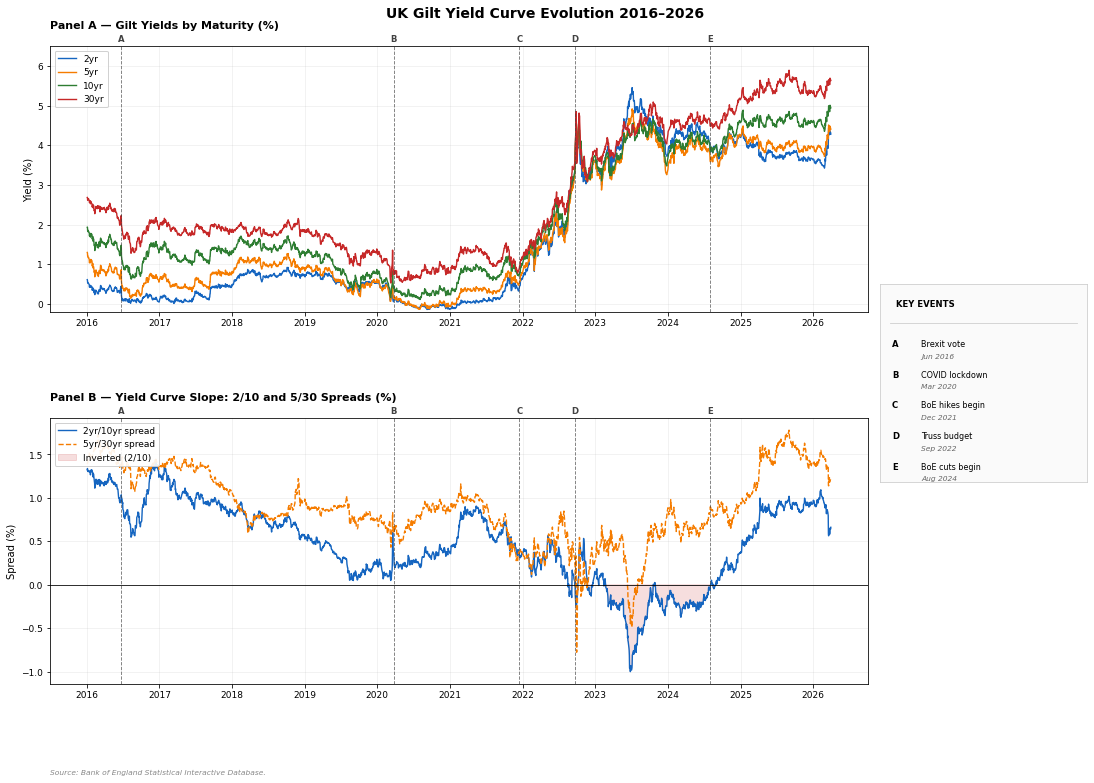

Chart 1 saved.


In [3]:
# ============================================================
# CHART 1 — UK GILT YIELD CURVE EVOLUTION 2016–2026
# ============================================================

event_dates = {
    'A': ('Brexit vote',     '2016-06-24'),
    'B': ('COVID lockdown',  '2020-03-23'),
    'C': ('BoE hikes begin', '2021-12-16'),
    'D': ('Truss budget',    '2022-09-23'),
    'E': ('BoE cuts begin',  '2024-08-01'),
}

fig, axes = plt.subplots(2, 1, figsize=(16, 11))
fig.suptitle('UK Gilt Yield Curve Evolution 2016–2026',
             fontsize=14, fontweight='bold', y=0.98)
fig.subplots_adjust(hspace=0.40, top=0.93, right=0.78, left=0.07)

mat_colors = {
    'uk_2yr':  '#1565C0',  # Dark blue
    'uk_5yr':  '#F57C00',  # Orange
    'uk_10yr': '#2E7D32',  # Green
    'uk_30yr': '#C62828',  # Red
}
mat_labels = {
    'uk_2yr': '2yr', 'uk_5yr': '5yr',
    'uk_10yr': '10yr', 'uk_30yr': '30yr'
}

# --- PANEL A: yield levels ---
ax1 = axes[0]
for col, color in mat_colors.items():
    ax1.plot(gilts_nominal.index.to_pydatetime(),
             gilts_nominal[col].values,
             color=color, linewidth=1.4,
             label=mat_labels[col])

for letter, (label, date) in event_dates.items():
    idx = gilts_nominal.index.get_indexer(
        [pd.Timestamp(date)], method='nearest')[0]
    x = gilts_nominal.index[idx].to_pydatetime()
    ax1.axvline(x=x, color=COLORS['event'],
                linestyle='--', linewidth=0.9, alpha=0.7)
    ax1.text(x, 1.01, letter, fontsize=8.5, ha='center',
             va='bottom', color=COLORS['event'], fontweight='bold',
             transform=ax1.get_xaxis_transform())

ax1.set_title('Panel A — Gilt Yields by Maturity (%)',
              loc='left', pad=18)
ax1.set_ylabel('Yield (%)')
ax1.legend(loc='upper left', framealpha=0.9)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax1.xaxis.set_major_locator(mdates.YearLocator())
ax1.set_ylim(-0.2, 6.5)

# --- PANEL B: curve slope ---
ax2 = axes[1]
ax2.plot(gilts_nominal.index.to_pydatetime(),
         gilts_nominal['spread_2_10'].values,
         color=COLORS['uk'], linewidth=1.4,
         label='2yr/10yr spread')
ax2.plot(gilts_nominal.index.to_pydatetime(),
         gilts_nominal['spread_5_30'].values,
         color=COLORS['breakeven'], linewidth=1.4,
         label='5yr/30yr spread', linestyle='--')
ax2.axhline(y=0, color='black', linewidth=0.8)
ax2.fill_between(gilts_nominal.index.to_pydatetime(),
                 gilts_nominal['spread_2_10'].values, 0,
                 where=gilts_nominal['spread_2_10'].values < 0,
                 alpha=0.15, color=COLORS['negative'],
                 label='Inverted (2/10)')

for letter, (label, date) in event_dates.items():
    idx = gilts_nominal.index.get_indexer(
        [pd.Timestamp(date)], method='nearest')[0]
    x = gilts_nominal.index[idx].to_pydatetime()
    ax2.axvline(x=x, color=COLORS['event'],
                linestyle='--', linewidth=0.9, alpha=0.7)
    ax2.text(x, 1.01, letter, fontsize=8.5, ha='center',
             va='bottom', color=COLORS['event'], fontweight='bold',
             transform=ax2.get_xaxis_transform())

ax2.set_title('Panel B — Yield Curve Slope: 2/10 and 5/30 Spreads (%)',
              loc='left', pad=18)
ax2.set_ylabel('Spread (%)')
ax2.legend(loc='upper left', framealpha=0.9)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax2.xaxis.set_major_locator(mdates.YearLocator())

# Key events legend box
ax_leg = fig.add_axes([0.79, 0.38, 0.18, 0.25])
ax_leg.set_xticks([])
ax_leg.set_yticks([])
ax_leg.set_xlim(0, 1)
ax_leg.set_ylim(0, 1)
for spine in ax_leg.spines.values():
    spine.set_edgecolor('#cccccc')
    spine.set_linewidth(0.8)
ax_leg.set_facecolor('#fafafa')

ax_leg.text(0.08, 0.92, 'KEY EVENTS', transform=ax_leg.transAxes,
            fontsize=8.5, fontweight='bold', va='top')
ax_leg.plot([0.05, 0.95], [0.80, 0.80], color='#cccccc',
            linewidth=0.8, transform=ax_leg.transAxes)

entries = [
    ('A', 'Brexit vote',     'Jun 2016'),
    ('B', 'COVID lockdown',  'Mar 2020'),
    ('C', 'BoE hikes begin', 'Dec 2021'),
    ('D', 'Truss budget',    'Sep 2022'),
    ('E', 'BoE cuts begin',  'Aug 2024'),
]
for i, (letter, desc, date) in enumerate(entries):
    y = 0.72 - i * 0.155
    ax_leg.text(0.06, y, letter, transform=ax_leg.transAxes,
                fontsize=8.5, fontweight='bold', va='top')
    ax_leg.text(0.20, y, desc, transform=ax_leg.transAxes,
                fontsize=8, va='top')
    ax_leg.text(0.20, y - 0.07, date, transform=ax_leg.transAxes,
                fontsize=7.5, va='top', color='#666666', style='italic')

fig.text(0.07, 0.01, SOURCE_BOE, fontsize=7.5,
         color='#888888', style='italic')

plt.savefig('outputs/charts/p01_yield_curve_evolution.png')
plt.show()
print("Chart 1 saved.")

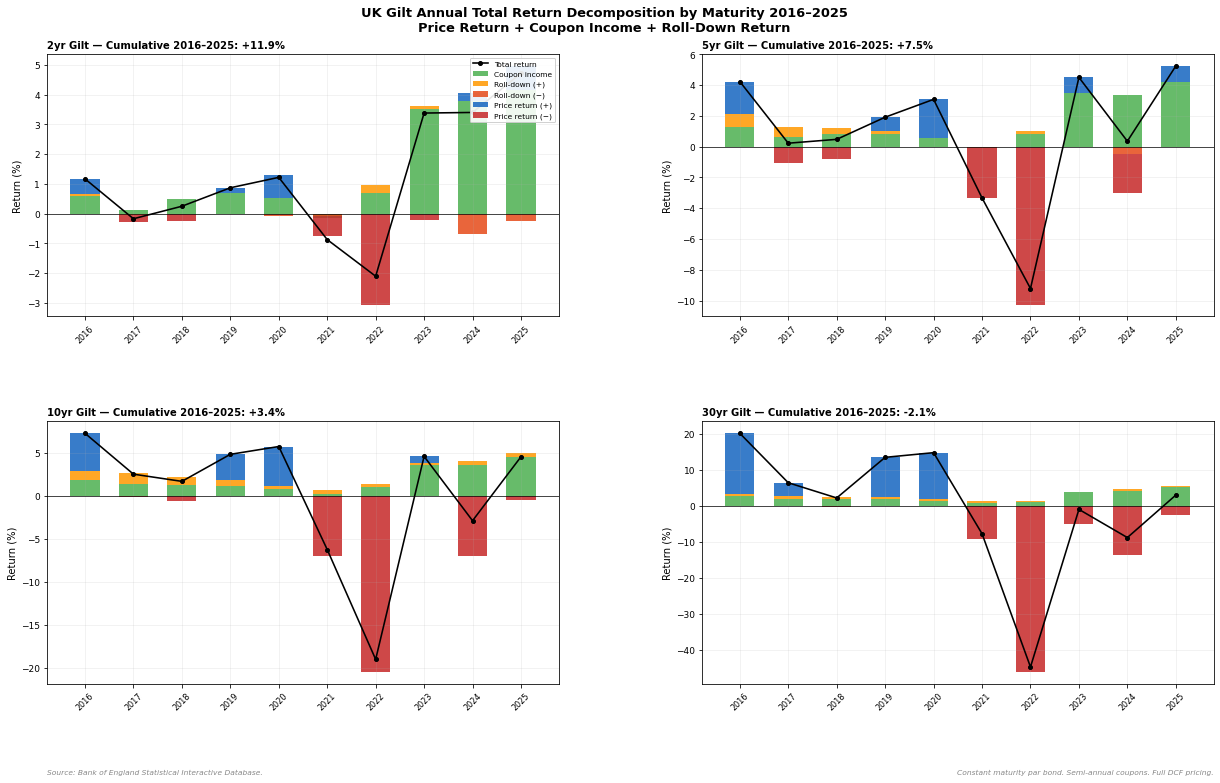

Chart 2 saved.


In [4]:
# ============================================================
# CHART 2 — ANNUAL TOTAL RETURN DECOMPOSITION
# ============================================================

# Rebuild total return data
def price_bond(yield_annual, coupon_annual, maturity_years, face=100):
    y = yield_annual / 2
    c = (coupon_annual / 2) * face
    n = int(maturity_years * 2)
    if n == 0: return face
    if y == 0: return c * n + face
    pv_coupons = c * (1 - (1 + y) ** (-n)) / y
    pv_face    = face * (1 + y) ** (-n)
    return pv_coupons + pv_face

def get_spot_yield(gilts_df, date, maturity):
    boe = pd.read_csv('data/processed/boe_rate.csv',
                      index_col=0, parse_dates=True)
    idx = gilts_df.index.get_indexer([pd.Timestamp(date)], method='nearest')[0]
    row = gilts_df.iloc[idx]
    available = {2: row['uk_2yr'], 5: row['uk_5yr'],
                 10: row['uk_10yr'], 30: row['uk_30yr']}
    if maturity in available:
        return available[maturity] / 100
    if maturity < 2:
        boe_idx = boe.index.get_indexer([pd.Timestamp(date)], method='nearest')[0]
        boe_rate = boe.iloc[boe_idx].values[0]
        y2 = available[2]
        return (boe_rate + (y2 - boe_rate) * (maturity / 2)) / 100
    mats = sorted(available.keys())
    for i in range(len(mats) - 1):
        if mats[i] < maturity < mats[i+1]:
            y0, y1 = available[mats[i]], available[mats[i+1]]
            m0, m1 = mats[i], mats[i+1]
            return (y0 + (y1 - y0) * (maturity - m0) / (m1 - m0)) / 100
    return available[30] / 100

def calculate_total_return(gilts_df, start_date, end_date, maturity):
    y_start = get_spot_yield(gilts_df, start_date, maturity)
    y_end   = get_spot_yield(gilts_df, end_date, maturity)
    holding_years = (pd.Timestamp(end_date) -
                     pd.Timestamp(start_date)).days / 365.25
    remaining_maturity = max(maturity - holding_years, 0.5)
    price_end  = price_bond(y_end, y_start, remaining_maturity)
    y_rolled   = get_spot_yield(gilts_df, start_date, remaining_maturity)
    price_rolled = price_bond(y_rolled, y_start, remaining_maturity)
    rolldown   = (price_rolled - 100) / 100 * 100
    pure_price = (price_end - 100) / 100 * 100 - rolldown
    coupon     = y_start * holding_years * 100
    return {
        'price_return':    round(pure_price, 2),
        'coupon_return':   round(coupon, 2),
        'rolldown_return': round(rolldown, 2),
        'total_return':    round(pure_price + coupon + rolldown, 2),
    }

# Calculate annual returns
years      = range(2016, 2026)
maturities = [2, 5, 10, 30]
annual_results = []

for year in years:
    year_data = gilts_nominal[gilts_nominal.index.year == year]
    start = year_data.index[0].strftime('%Y-%m-%d')
    end   = year_data.index[-1].strftime('%Y-%m-%d')
    for mat in maturities:
        ret = calculate_total_return(gilts_nominal, start, end, mat)
        annual_results.append({'year': year, 'maturity': f"{mat}yr", **ret})

annual_df = pd.DataFrame(annual_results)

pivot_price    = annual_df.pivot_table(index='year', columns='maturity',
                                        values='price_return')[['2yr','5yr','10yr','30yr']]
pivot_coupon   = annual_df.pivot_table(index='year', columns='maturity',
                                        values='coupon_return')[['2yr','5yr','10yr','30yr']]
pivot_rolldown = annual_df.pivot_table(index='year', columns='maturity',
                                        values='rolldown_return')[['2yr','5yr','10yr','30yr']]
pivot_total    = annual_df.pivot_table(index='year', columns='maturity',
                                        values='total_return')[['2yr','5yr','10yr','30yr']]

# Chart
years_list = list(years)
mats_plot  = ['2yr', '5yr', '10yr', '30yr']
x          = np.arange(len(years_list))
width      = 0.18

mat_colors_bar = {
    '2yr':  COLORS['uk_2yr'],
    '5yr':  '#F57C00',
    '10yr': '#2E7D32',
    '30yr': COLORS['negative'],
}

fig, axes = plt.subplots(2, 2, figsize=(18, 11))
fig.suptitle('UK Gilt Annual Total Return Decomposition by Maturity 2016–2025\n'
             'Price Return + Coupon Income + Roll-Down Return',
             fontsize=13, fontweight='bold', y=0.98)
fig.subplots_adjust(hspace=0.40, wspace=0.28, top=0.92,
                    left=0.07, right=0.97)

component_colors = {
    'Coupon income':    '#4CAF50',
    'Roll-down (+)':    '#FF9800',
    'Roll-down (−)':    '#E64A19',
    'Price return (+)': '#1565C0',
    'Price return (−)': '#C62828',
}

for idx, mat in enumerate(mats_plot):
    ax = axes[idx // 2][idx % 2]

    price    = pivot_price[mat].values
    coupon   = pivot_coupon[mat].values
    rolldown = pivot_rolldown[mat].values
    total    = pivot_total[mat].values

    pos_bottom = np.zeros(len(x))
    neg_bottom = np.zeros(len(x))

    # Coupon — always positive
    ax.bar(x, coupon, color=component_colors['Coupon income'],
           alpha=0.85, width=0.6, label='Coupon income')
    pos_bottom += coupon

    # Roll-down
    rd_pos = np.where(rolldown >= 0, rolldown, 0)
    rd_neg = np.where(rolldown < 0,  rolldown, 0)
    if rd_pos.any():
        ax.bar(x, rd_pos, bottom=pos_bottom,
               color=component_colors['Roll-down (+)'],
               alpha=0.85, width=0.6, label='Roll-down (+)')
        pos_bottom += rd_pos
    if rd_neg.any():
        ax.bar(x, rd_neg, bottom=neg_bottom,
               color=component_colors['Roll-down (−)'],
               alpha=0.85, width=0.6, label='Roll-down (−)')
        neg_bottom += rd_neg

    # Price return
    pr_pos = np.where(price >= 0, price, 0)
    pr_neg = np.where(price < 0,  price, 0)
    if pr_pos.any():
        ax.bar(x, pr_pos, bottom=pos_bottom,
               color=component_colors['Price return (+)'],
               alpha=0.85, width=0.6, label='Price return (+)')
    if pr_neg.any():
        ax.bar(x, pr_neg, bottom=neg_bottom,
               color=component_colors['Price return (−)'],
               alpha=0.85, width=0.6, label='Price return (−)')

    # Total return line
    ax.plot(x, total, color='black', linewidth=1.6,
            marker='o', markersize=4, label='Total return', zorder=5)
    ax.axhline(y=0, color='black', linewidth=0.7)

    ax.set_title(f'{mat} Gilt — Cumulative 2016–2025: '
                 f'{pivot_total[mat].sum():+.1f}%',
                 loc='left', fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels(years_list, rotation=45, fontsize=8)
    ax.set_ylabel('Return (%)')

    if idx == 0:
        ax.legend(fontsize=7.5, loc='upper right', framealpha=0.9)

fig.text(0.07, 0.01, SOURCE_BOE, fontsize=7.5,
         color='#888888', style='italic')
fig.text(0.97, 0.01,
         'Constant maturity par bond. Semi-annual coupons. Full DCF pricing.',
         fontsize=7.5, color='#888888', style='italic', ha='right')

plt.savefig('outputs/charts/p02_annual_total_return.png')
plt.show()
print("Chart 2 saved.")

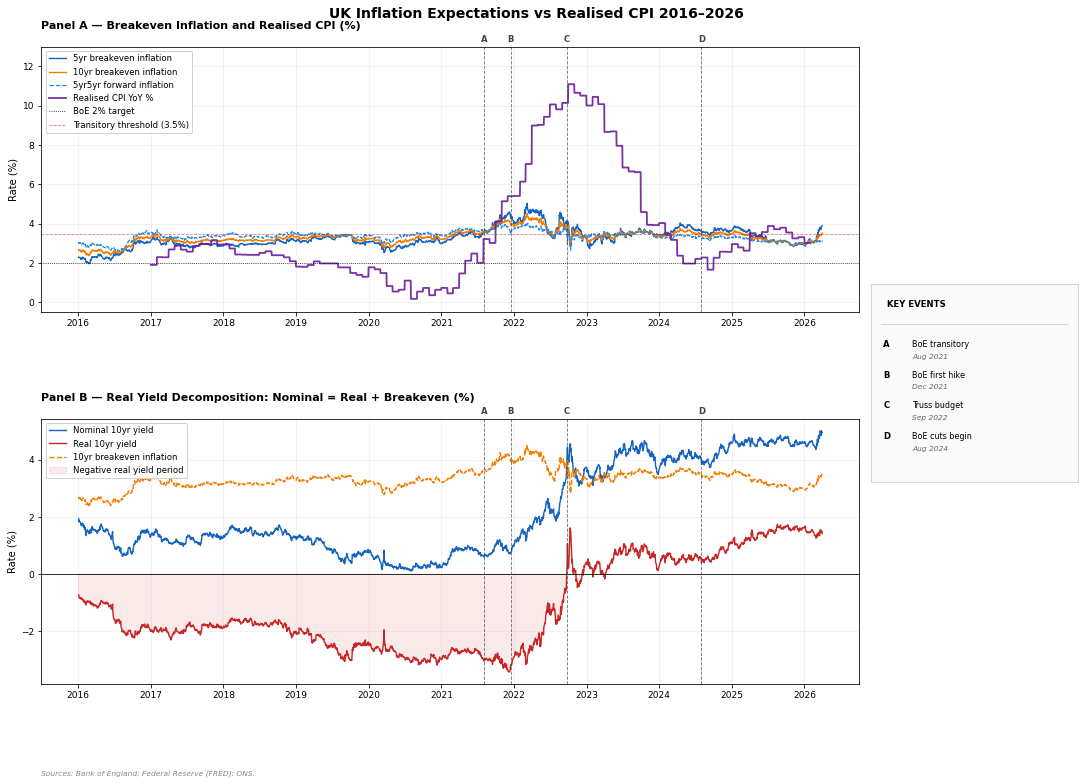

Chart 3 saved.


In [6]:
# ============================================================
# CHART 3 — BREAKEVEN INFLATION vs REALISED CPI
# ============================================================

fig, axes = plt.subplots(2, 1, figsize=(16, 11))
fig.suptitle('UK Inflation Expectations vs Realised CPI 2016–2026',
             fontsize=14, fontweight='bold', y=0.98)
fig.subplots_adjust(hspace=0.40, top=0.93, right=0.78, left=0.07)

event_dates = {
    'A': ('BoE transitory language', '2021-08-05'),
    'B': ('BoE first hike',          '2021-12-16'),
    'C': ('Truss budget',            '2022-09-23'),
    'D': ('BoE cuts begin',          '2024-08-01'),
}

# --- PANEL A: breakevens vs CPI ---
ax1 = axes[0]

ax1.plot(breakevens.index.to_pydatetime(),
         breakevens['be_5yr'].values,
         color=COLORS['uk_2yr'], linewidth=1.4,
         label='5yr breakeven inflation')
ax1.plot(breakevens.index.to_pydatetime(),
         breakevens['be_10yr'].values,
         color=COLORS['breakeven'], linewidth=1.4,
         label='10yr breakeven inflation')
ax1.plot(breakevens.index.to_pydatetime(),
         breakevens['fwd_5y5y'].values,
         color=COLORS['uk_5yr'], linewidth=1.2,
         linestyle='--', label='5yr5yr forward inflation')
ax1.plot(cpi_daily.index.to_pydatetime(),
         cpi_daily.values,
         color=COLORS['cpi'], linewidth=1.8,
         label='Realised CPI YoY %', alpha=0.9)

ax1.axhline(y=2.0, color='black', linewidth=0.8,
            linestyle=':', label='BoE 2% target')
ax1.axhline(y=3.5, color=COLORS['negative'], linewidth=0.8,
            linestyle='--', alpha=0.6,
            label='Transitory threshold (3.5%)')

for letter, (label, date) in event_dates.items():
    idx = breakevens.index.get_indexer(
        [pd.Timestamp(date)], method='nearest')[0]
    x = breakevens.index[idx].to_pydatetime()
    ax1.axvline(x=x, color=COLORS['event'],
                linestyle='--', linewidth=0.9, alpha=0.7)
    ax1.text(x, 1.01, letter, fontsize=8.5, ha='center',
             va='bottom', color=COLORS['event'], fontweight='bold',
             transform=ax1.get_xaxis_transform())

ax1.set_title('Panel A — Breakeven Inflation and Realised CPI (%)',
              loc='left', pad=18)
ax1.set_ylabel('Rate (%)')
ax1.legend(loc='upper left', framealpha=0.9, fontsize=8.5)
ax1.set_ylim(-0.5, 13)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax1.xaxis.set_major_locator(mdates.YearLocator())

# --- PANEL B: real yield decomposition ---
ax2 = axes[1]

ax2.plot(breakevens.index.to_pydatetime(),
         breakevens['nom_10yr'].values,
         color=COLORS['nominal'], linewidth=1.4,
         label='Nominal 10yr yield')
ax2.plot(breakevens.index.to_pydatetime(),
         breakevens['real_10yr'].values,
         color=COLORS['real'], linewidth=1.4,
         label='Real 10yr yield')
ax2.plot(breakevens.index.to_pydatetime(),
         breakevens['be_10yr'].values,
         color=COLORS['breakeven'], linewidth=1.4,
         linestyle='--', label='10yr breakeven inflation')
ax2.axhline(y=0, color='black', linewidth=0.8)

# Shade negative real yield period
ax2.fill_between(breakevens.index.to_pydatetime(),
                 breakevens['real_10yr'].values, 0,
                 where=breakevens['real_10yr'].values < 0,
                 alpha=0.10, color=COLORS['negative'],
                 label='Negative real yield period')

for letter, (label, date) in event_dates.items():
    idx = breakevens.index.get_indexer(
        [pd.Timestamp(date)], method='nearest')[0]
    x = breakevens.index[idx].to_pydatetime()
    ax2.axvline(x=x, color=COLORS['event'],
                linestyle='--', linewidth=0.9, alpha=0.7)
    ax2.text(x, 1.01, letter, fontsize=8.5, ha='center',
             va='bottom', color=COLORS['event'], fontweight='bold',
             transform=ax2.get_xaxis_transform())

ax2.set_title('Panel B — Real Yield Decomposition: '
              'Nominal = Real + Breakeven (%)',
              loc='left', pad=18)
ax2.set_ylabel('Rate (%)')
ax2.legend(loc='upper left', framealpha=0.9, fontsize=8.5)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax2.xaxis.set_major_locator(mdates.YearLocator())

# Key events legend
ax_leg = fig.add_axes([0.79, 0.38, 0.18, 0.25])
ax_leg.set_xticks([])
ax_leg.set_yticks([])
ax_leg.set_xlim(0, 1)
ax_leg.set_ylim(0, 1)
for spine in ax_leg.spines.values():
    spine.set_edgecolor('#cccccc')
    spine.set_linewidth(0.8)
ax_leg.set_facecolor('#fafafa')

ax_leg.text(0.08, 0.92, 'KEY EVENTS',
            transform=ax_leg.transAxes,
            fontsize=8.5, fontweight='bold', va='top')
ax_leg.plot([0.05, 0.95], [0.80, 0.80], color='#cccccc',
            linewidth=0.8, transform=ax_leg.transAxes)

entries = [
    ('A', 'BoE transitory',  'Aug 2021'),
    ('B', 'BoE first hike',  'Dec 2021'),
    ('C', 'Truss budget',    'Sep 2022'),
    ('D', 'BoE cuts begin',  'Aug 2024'),
]
for i, (letter, desc, date) in enumerate(entries):
    y = 0.72 - i * 0.155
    ax_leg.text(0.06, y, letter, transform=ax_leg.transAxes,
                fontsize=8.5, fontweight='bold', va='top')
    ax_leg.text(0.20, y, desc, transform=ax_leg.transAxes,
                fontsize=8, va='top')
    ax_leg.text(0.20, y - 0.07, date, transform=ax_leg.transAxes,
                fontsize=7.5, va='top', color='#666666',
                style='italic')

fig.text(0.07, 0.01, SOURCE_MULTI, fontsize=7.5,
         color='#888888', style='italic')

plt.savefig('outputs/charts/p03_inflation_expectations.png')
plt.show()
print("Chart 3 saved.")

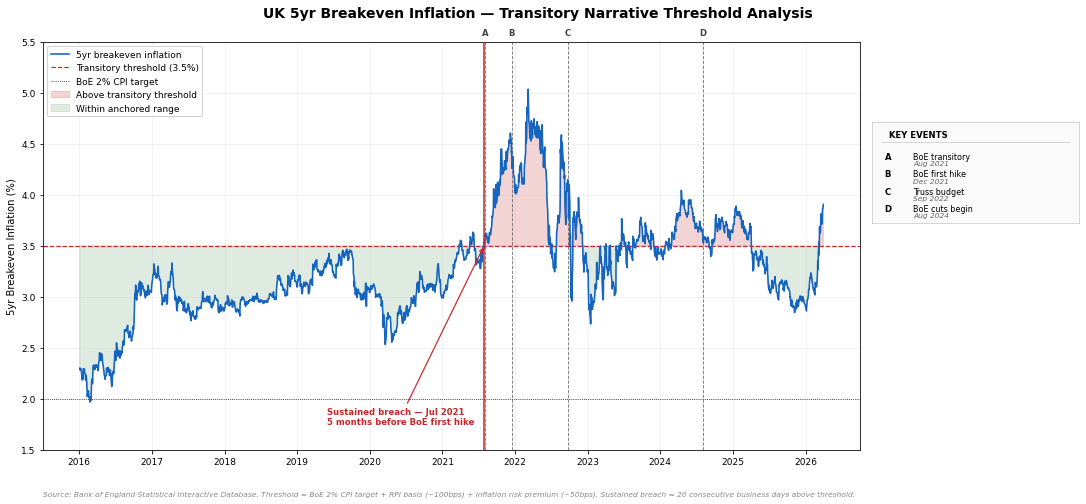

Chart 4 saved.


In [8]:
THRESHOLD     = 3.5
SUSTAINED     = 20
be_5yr        = breakevens['be_5yr'].copy()
above         = be_5yr > THRESHOLD
breach_date   = None
consecutive   = 0

for date, ab in above.items():
    if ab:
        consecutive += 1
        if consecutive >= SUSTAINED and breach_date is None:
            breach_date = be_5yr.index[
                be_5yr.index.get_indexer(
                    [date - pd.offsets.BDay(SUSTAINED - 1)],
                    method='nearest')[0]]
    else:
        consecutive = 0

fig, ax = plt.subplots(figsize=(16, 7))
fig.suptitle('UK 5yr Breakeven Inflation — Transitory Narrative Threshold Analysis',
             fontsize=14, fontweight='bold', y=0.98)
fig.subplots_adjust(top=0.91, left=0.07, right=0.78, bottom=0.10)

# Shade above and below threshold
ax.fill_between(be_5yr.index.to_pydatetime(),
                be_5yr.values, THRESHOLD,
                where=be_5yr.values > THRESHOLD,
                alpha=0.20, color=COLORS['negative'],
                label='Above transitory threshold')
ax.fill_between(be_5yr.index.to_pydatetime(),
                be_5yr.values, THRESHOLD,
                where=be_5yr.values <= THRESHOLD,
                alpha=0.15, color=COLORS['positive'],
                label='Within anchored range')

# 5yr breakeven line
ax.plot(be_5yr.index.to_pydatetime(), be_5yr.values,
        color=COLORS['uk_2yr'], linewidth=1.6,
        label='5yr breakeven inflation', zorder=3)

# Threshold and target lines
ax.axhline(y=THRESHOLD, color=COLORS['negative'], linewidth=1.2,
           linestyle='--', label=f'Transitory threshold ({THRESHOLD}%)')
ax.axhline(y=2.0, color='black', linewidth=0.8,
           linestyle=':', label='BoE 2% CPI target')

# Breach date vertical line
ax.axvline(x=breach_date.to_pydatetime(),
           color=COLORS['negative'], linewidth=1.8,
           linestyle='-', alpha=0.85, zorder=4)

# Key events — letter system, no rotation
event_dates = {
    'A': ('BoE transitory language', '2021-08-05'),
    'B': ('BoE first hike',          '2021-12-16'),
    'C': ('Truss budget',            '2022-09-23'),
    'D': ('BoE cuts begin',          '2024-08-01'),
}

for letter, (label, date) in event_dates.items():
    idx = be_5yr.index.get_indexer(
        [pd.Timestamp(date)], method='nearest')[0]
    x = be_5yr.index[idx].to_pydatetime()
    ax.axvline(x=x, color=COLORS['event'],
               linestyle='--', linewidth=0.9, alpha=0.7)
    ax.text(x, 1.01, letter, fontsize=8.5, ha='center',
             va='bottom', color=COLORS['event'], fontweight='bold',
             transform=ax.get_xaxis_transform())

# Breach annotation — positioned below the line cleanly
ax.annotate(f'Sustained breach — {breach_date.strftime("%b %Y")}\n'
            f'5 months before BoE first hike',
            xy=(breach_date.to_pydatetime(), THRESHOLD),
            xytext=(pd.Timestamp('2019-06-01'), 1.75),
            fontsize=8.5, color=COLORS['negative'], fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=COLORS['negative'],
                           lw=1.2))

ax.set_ylabel('5yr Breakeven Inflation (%)')
ax.set_ylim(1.5, 5.5)
ax.legend(loc='upper left', framealpha=0.9, fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())

# Key events legend box
ax_leg = fig.add_axes([0.79, 0.55, 0.18, 0.20])
ax_leg.set_xticks([])
ax_leg.set_yticks([])
ax_leg.set_xlim(0, 1)
ax_leg.set_ylim(0, 1)
for spine in ax_leg.spines.values():
    spine.set_edgecolor('#cccccc')
    spine.set_linewidth(0.8)
ax_leg.set_facecolor('#fafafa')

ax_leg.text(0.08, 0.92, 'KEY EVENTS',
            transform=ax_leg.transAxes,
            fontsize=8.5, fontweight='bold', va='top')
ax_leg.plot([0.05, 0.95], [0.80, 0.80], color='#cccccc',
            linewidth=0.8, transform=ax_leg.transAxes)

entries = [
    ('A', 'BoE transitory',  'Aug 2021'),
    ('B', 'BoE first hike',  'Dec 2021'),
    ('C', 'Truss budget',    'Sep 2022'),
    ('D', 'BoE cuts begin',  'Aug 2024'),
]
for i, (letter, desc, date) in enumerate(entries):
    y = 0.70 - i * 0.17
    ax_leg.text(0.06, y, letter, transform=ax_leg.transAxes,
                fontsize=8.5, fontweight='bold', va='top')
    ax_leg.text(0.20, y, desc, transform=ax_leg.transAxes,
                fontsize=8, va='top')
    ax_leg.text(0.20, y - 0.08, date, transform=ax_leg.transAxes,
                fontsize=7.5, va='top', color='#666666', style='italic')

fig.text(0.07, 0.01,
         SOURCE_BOE + ' Threshold = BoE 2% CPI target + RPI basis (~100bps) '
         '+ inflation risk premium (~50bps). Sustained breach = '
         f'{SUSTAINED} consecutive business days above threshold.',
         fontsize=7.5, color='#888888', style='italic')

plt.savefig('outputs/charts/p04_transitory_threshold.png')
plt.show()
print("Chart 4 saved.")

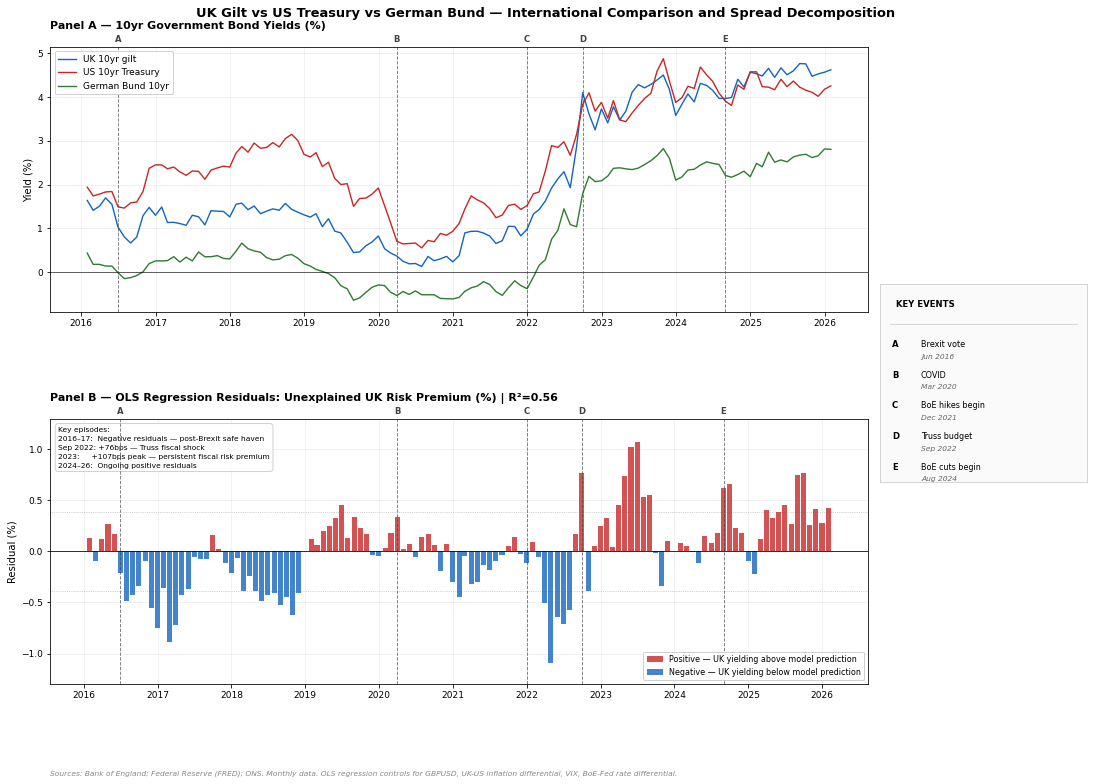

Chart 5 saved.


In [10]:
# ============================================================
# CHART 5 — INTERNATIONAL COMPARISON AND REGRESSION RESIDUALS
# ============================================================

# Build monthly master dataset
gilts_monthly   = gilts_nominal[['uk_2yr','uk_10yr','uk_30yr']].resample('M').last()
us_monthly      = us_treasuries[['us_10yr']].resample('M').last()
de_monthly      = german_bund[['de_10yr']].resample('M').last()
macro_monthly   = macro[['vix','gbpusd']].resample('M').last()
inf_monthly     = inflation_curve[['uk_inf_10yr']].resample('M').last()
tips_monthly    = pd.read_csv('data/processed/us_tips.csv',
                               index_col=0, parse_dates=True)
tips_monthly    = tips_monthly[['us_breakeven_10yr']].resample('M').last()

master = pd.concat([gilts_monthly, us_monthly, de_monthly,
                    macro_monthly, inf_monthly, tips_monthly], axis=1)
master = master.dropna(subset=['uk_10yr','us_10yr','de_10yr'])
master['gilt_treasury_spread'] = master['uk_10yr'] - master['us_10yr']
master['uk_us_inf_diff']       = (master['uk_inf_10yr'] -
                                   master['us_breakeven_10yr'])

# Load policy rates
fed    = pd.read_csv('data/processed/fed_funds.csv',
                      index_col=0, parse_dates=True)
boe_r  = pd.read_csv('data/processed/boe_rate.csv',
                      index_col=0, parse_dates=True)
fed.columns   = ['fed_funds']
boe_r.columns = ['boe_rate']
fed_m  = fed.resample('M').last()
boe_m  = boe_r.resample('M').last()
master['fed_funds'] = fed_m['fed_funds']
master['boe_rate']  = boe_m['boe_rate']
master['rate_diff'] = master['boe_rate'] - master['fed_funds']

# OLS regression
reg = master[['gilt_treasury_spread','gbpusd',
              'uk_us_inf_diff','vix','rate_diff']].dropna()
Y   = reg['gilt_treasury_spread'].values
X   = np.column_stack([
    np.ones(len(reg)),
    reg['gbpusd'].values,
    reg['uk_us_inf_diff'].values,
    reg['vix'].values,
    reg['rate_diff'].values,
])
beta      = np.linalg.inv(X.T @ X) @ X.T @ Y
Y_hat     = X @ beta
residuals = Y - Y_hat
reg = reg.copy()
reg['fitted']    = Y_hat
reg['residuals'] = residuals

# Chart
fig, axes = plt.subplots(2, 1, figsize=(16, 11))
fig.suptitle('UK Gilt vs US Treasury vs German Bund — '
             'International Comparison and Spread Decomposition',
             fontsize=13, fontweight='bold', y=0.98)
fig.subplots_adjust(hspace=0.40, top=0.93, right=0.78, left=0.07)

event_dates = {
    'A': ('Brexit vote',     '2016-06-30'),
    'B': ('COVID',           '2020-03-31'),
    'C': ('BoE hikes begin', '2021-12-31'),
    'D': ('Truss budget',    '2022-09-30'),
    'E': ('BoE cuts begin',  '2024-08-31'),
}

# --- PANEL A: 10yr yields ---
ax1 = axes[0]
ax1.plot(master.index.to_pydatetime(), master['uk_10yr'].values,
         color=COLORS['uk'], linewidth=1.4, label='UK 10yr gilt')
ax1.plot(master.index.to_pydatetime(), master['us_10yr'].values,
         color=COLORS['us'], linewidth=1.4, label='US 10yr Treasury')
ax1.plot(master.index.to_pydatetime(), master['de_10yr'].values,
         color=COLORS['de'], linewidth=1.4, label='German Bund 10yr')
ax1.axhline(y=0, color='black', linewidth=0.6)

for letter, (label, date) in event_dates.items():
    idx = master.index.get_indexer(
        [pd.Timestamp(date)], method='nearest')[0]
    x = master.index[idx].to_pydatetime()
    ax1.axvline(x=x, color=COLORS['event'],
                linestyle='--', linewidth=0.9, alpha=0.7)
    ax1.text(x, 1.01, letter, fontsize=8.5, ha='center',
             va='bottom', color=COLORS['event'], fontweight='bold',
             transform=ax1.get_xaxis_transform())

ax1.set_title('Panel A — 10yr Government Bond Yields (%)',
              loc='left', pad=18)
ax1.set_ylabel('Yield (%)')
ax1.legend(loc='upper left', framealpha=0.9)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax1.xaxis.set_major_locator(mdates.YearLocator())

# --- PANEL B: residuals — clean version ---
ax2 = axes[1]

bar_colors = [COLORS['negative'] if r > 0 else COLORS['uk']
              for r in reg['residuals'].values]
ax2.bar(reg.index.to_pydatetime(), reg['residuals'].values,
        color=bar_colors, alpha=0.80, width=25, zorder=3)
ax2.axhline(y=0, color='black', linewidth=0.8, zorder=4)

# One std dev reference lines
std_resid = reg['residuals'].std()
ax2.axhline(y=std_resid, color='#888888', linewidth=0.7,
            linestyle=':', alpha=0.7, zorder=2,
            label=f'±1 std dev (±{std_resid:.2f}%)')
ax2.axhline(y=-std_resid, color='#888888', linewidth=0.7,
            linestyle=':', alpha=0.7, zorder=2)

for letter, (label, date) in event_dates.items():
    idx = master.index.get_indexer(
        [pd.Timestamp(date)], method='nearest')[0]
    x = master.index[idx].to_pydatetime()
    ax2.axvline(x=x, color=COLORS['event'],
                linestyle='--', linewidth=0.9, alpha=0.7, zorder=5)
    ax2.text(x, 1.01, letter, fontsize=8.5, ha='center',
             va='bottom', color=COLORS['event'], fontweight='bold',
             transform=ax2.get_xaxis_transform())

# Clean episode summary text box
episode_text = (
    "Key episodes:\n"
    "2016–17:  Negative residuals — post-Brexit safe haven\n"
    "Sep 2022: +76bps — Truss fiscal shock\n"
    "2023:     +107bps peak — persistent fiscal risk premium\n"
    "2024–26:  Ongoing positive residuals"
)
ax2.text(0.01, 0.97, episode_text,
         transform=ax2.transAxes,
         fontsize=7.5, va='top', ha='left',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                   edgecolor='#cccccc', alpha=0.9),
         linespacing=1.6)

ax2.set_title('Panel B — OLS Regression Residuals: '
              'Unexplained UK Risk Premium (%) | R²=0.56',
              loc='left', pad=18)
ax2.set_ylabel('Residual (%)')
ax2.set_ylim(-1.3, 1.3)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax2.xaxis.set_major_locator(mdates.YearLocator())

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=COLORS['negative'], alpha=0.80,
          label='Positive — UK yielding above model prediction'),
    Patch(facecolor=COLORS['uk'], alpha=0.80,
          label='Negative — UK yielding below model prediction'),
]
ax2.legend(handles=legend_elements, loc='lower right',
           fontsize=8, framealpha=0.9)

# Key events legend box
ax_leg = fig.add_axes([0.79, 0.38, 0.18, 0.25])
ax_leg.set_xticks([])
ax_leg.set_yticks([])
ax_leg.set_xlim(0, 1)
ax_leg.set_ylim(0, 1)
for spine in ax_leg.spines.values():
    spine.set_edgecolor('#cccccc')
    spine.set_linewidth(0.8)
ax_leg.set_facecolor('#fafafa')

ax_leg.text(0.08, 0.92, 'KEY EVENTS',
            transform=ax_leg.transAxes,
            fontsize=8.5, fontweight='bold', va='top')
ax_leg.plot([0.05, 0.95], [0.80, 0.80], color='#cccccc',
            linewidth=0.8, transform=ax_leg.transAxes)

entries = [
    ('A', 'Brexit vote',     'Jun 2016'),
    ('B', 'COVID',           'Mar 2020'),
    ('C', 'BoE hikes begin', 'Dec 2021'),
    ('D', 'Truss budget',    'Sep 2022'),
    ('E', 'BoE cuts begin',  'Aug 2024'),
]
for i, (letter, desc, date) in enumerate(entries):
    y = 0.72 - i * 0.155
    ax_leg.text(0.06, y, letter, transform=ax_leg.transAxes,
                fontsize=8.5, fontweight='bold', va='top')
    ax_leg.text(0.20, y, desc, transform=ax_leg.transAxes,
                fontsize=8, va='top')
    ax_leg.text(0.20, y - 0.07, date, transform=ax_leg.transAxes,
                fontsize=7.5, va='top', color='#666666',
                style='italic')

fig.text(0.07, 0.01,
         SOURCE_MULTI + ' Monthly data. OLS regression controls for '
         'GBPUSD, UK-US inflation differential, VIX, '
         'BoE-Fed rate differential.',
         fontsize=7.5, color='#888888', style='italic')

plt.savefig('outputs/charts/p05_international_regression.png')
plt.show()
print("Chart 5 saved.")

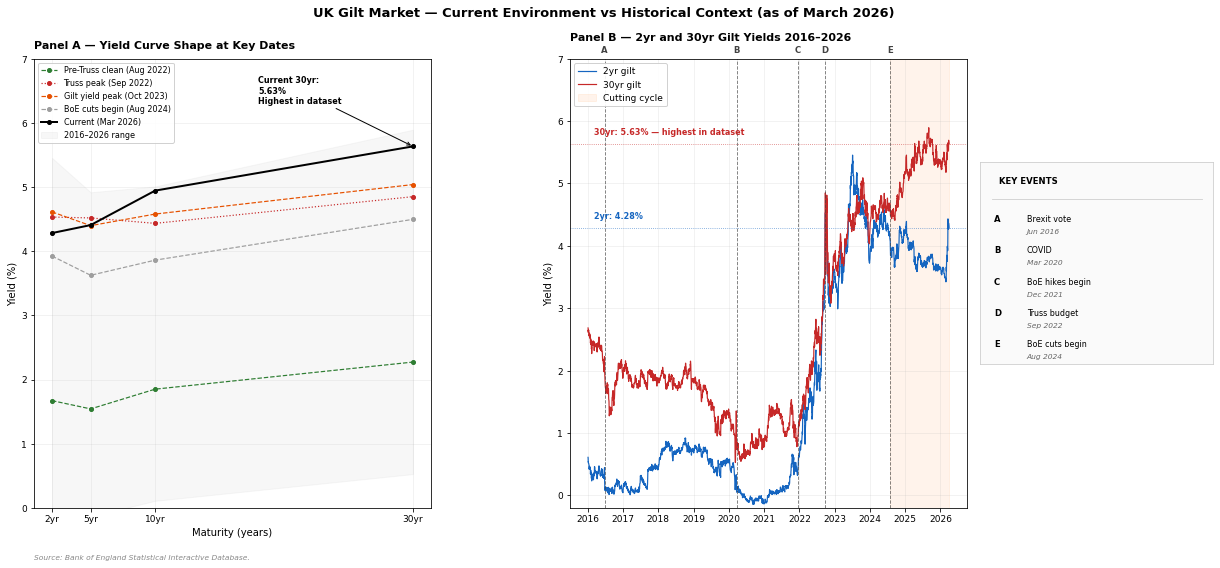

Chart 7 saved.


In [13]:
# ============================================================
# CHART 7 — CURRENT ENVIRONMENT SNAPSHOT — FIXED
# ============================================================

def get_yields(date):
    idx = gilts_nominal.index.get_indexer([date], method='nearest')[0]
    return gilts_nominal.iloc[idx]

CURRENT_DATE    = gilts_nominal.index[-1]
PRE_TRUSS_CLEAN = pd.Timestamp('2022-08-01')
TRUSS_PEAK      = pd.Timestamp('2022-09-27')
YIELD_PEAK      = pd.Timestamp('2023-10-06')
CUTS_BEGIN      = pd.Timestamp('2024-08-01')

maturities    = [2, 5, 10, 30]
maturity_cols = ['uk_2yr', 'uk_5yr', 'uk_10yr', 'uk_30yr']

hist_min = gilts_nominal[maturity_cols].min()
hist_max = gilts_nominal[maturity_cols].max()
current  = get_yields(CURRENT_DATE)

curves = {
    'Pre-Truss clean (Aug 2022)':         (PRE_TRUSS_CLEAN, '#2E7D32', '--', 1.2),
    'Truss peak (Sep 2022)':              (TRUSS_PEAK,      '#C62828', ':',  1.2),
    'Gilt yield peak (Oct 2023)':         (YIELD_PEAK,      '#E65100', '--', 1.2),
    'BoE cuts begin (Aug 2024)':          (CUTS_BEGIN,      '#9E9E9E', '--', 1.2),
    f'Current ({CURRENT_DATE.strftime("%b %Y")})':
                                          (CURRENT_DATE,    '#000000', '-',  2.0),
}

event_dates_ts = {
    'A': ('Brexit vote',     pd.Timestamp('2016-06-24')),
    'B': ('COVID',           pd.Timestamp('2020-03-23')),
    'C': ('BoE hikes begin', pd.Timestamp('2021-12-16')),
    'D': ('Truss budget',    pd.Timestamp('2022-09-23')),
    'E': ('BoE cuts begin',  pd.Timestamp('2024-08-01')),
}

fig, axes = plt.subplots(1, 2, figsize=(18, 8), facecolor='white')
fig.suptitle(f'UK Gilt Market — Current Environment vs Historical Context '
             f'(as of {CURRENT_DATE.strftime("%B %Y")})',
             fontsize=13, fontweight='bold', y=0.97)
fig.subplots_adjust(top=0.88, wspace=0.35, left=0.06,
                    right=0.78, bottom=0.10)

# --- LEFT PANEL: yield curve shapes ---
ax1 = axes[0]

ax1.fill_between(maturities,
                 [hist_min[col] for col in maturity_cols],
                 [hist_max[col] for col in maturity_cols],
                 alpha=0.08, color='#9E9E9E',
                 label='2016–2026 range')

for label, (date, color, style, lw) in curves.items():
    data = get_yields(date)
    vals = [data[col] for col in maturity_cols]
    ax1.plot(maturities, vals, color=color, linestyle=style,
             linewidth=lw, label=label, marker='o', markersize=4)

ax1.annotate(
    f'Current 30yr:\n{current["uk_30yr"]:.2f}%\nHighest in dataset',
    xy=(30, current['uk_30yr']),
    xytext=(18, 6.3),
    fontsize=8, color='black', fontweight='bold',
    arrowprops=dict(arrowstyle='->', color='black', lw=1.0))

ax1.set_title('Panel A — Yield Curve Shape at Key Dates',
              loc='left', fontsize=11, fontweight='bold', pad=10)
ax1.set_xlabel('Maturity (years)')
ax1.set_ylabel('Yield (%)')
ax1.set_xticks(maturities)
ax1.set_xticklabels(['2yr', '5yr', '10yr', '30yr'])
ax1.legend(fontsize=8, framealpha=0.9, loc='upper left')
ax1.set_ylim(0, 7)

# --- RIGHT PANEL: time series ---
ax2 = axes[1]

ax2.plot(gilts_nominal.index.to_pydatetime(),
         gilts_nominal['uk_2yr'].values,
         color=COLORS['uk_2yr'], linewidth=1.2, label='2yr gilt')
ax2.plot(gilts_nominal.index.to_pydatetime(),
         gilts_nominal['uk_30yr'].values,
         color=COLORS['negative'], linewidth=1.2, label='30yr gilt')

# Shade cutting cycle
ax2.axvspan(CUTS_BEGIN.to_pydatetime(),
            CURRENT_DATE.to_pydatetime(),
            alpha=0.08, color='#FF6F00', label='Cutting cycle')

# Current level dotted lines
ax2.axhline(y=current['uk_2yr'], color=COLORS['uk_2yr'],
            linewidth=0.8, linestyle=':', alpha=0.7)
ax2.axhline(y=current['uk_30yr'], color=COLORS['negative'],
            linewidth=0.8, linestyle=':', alpha=0.7)

# Current level labels — inside left of chart
ax2.text(pd.Timestamp('2016-03-01').to_pydatetime(),
         current['uk_2yr'] + 0.15,
         f"2yr: {current['uk_2yr']:.2f}%",
         fontsize=8, color=COLORS['uk_2yr'], fontweight='bold')
ax2.text(pd.Timestamp('2016-03-01').to_pydatetime(),
         current['uk_30yr'] + 0.15,
         f"30yr: {current['uk_30yr']:.2f}% — highest in dataset",
         fontsize=8, color=COLORS['negative'], fontweight='bold')

# A-E event lines
for letter, (label, date) in event_dates_ts.items():
    x = date.to_pydatetime()
    ax2.axvline(x=x, color=COLORS['event'],
                linestyle='--', linewidth=0.9, alpha=0.7)
    ax2.text(x, 1.01, letter, fontsize=8.5, ha='center',
             va='bottom', color=COLORS['event'], fontweight='bold',
             transform=ax2.get_xaxis_transform())

ax2.set_title('Panel B — 2yr and 30yr Gilt Yields 2016–2026',
              loc='left', fontsize=11, fontweight='bold', pad=18)
ax2.set_ylabel('Yield (%)')
ax2.legend(loc='upper left', fontsize=9, framealpha=0.9)
ax2.set_ylim(-0.2, 7)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax2.xaxis.set_major_locator(mdates.YearLocator())

# Key events legend box
ax_leg = fig.add_axes([0.79, 0.35, 0.18, 0.35])
ax_leg.set_xticks([])
ax_leg.set_yticks([])
ax_leg.set_xlim(0, 1)
ax_leg.set_ylim(0, 1)
for spine in ax_leg.spines.values():
    spine.set_edgecolor('#cccccc')
    spine.set_linewidth(0.8)
ax_leg.set_facecolor('#fafafa')

ax_leg.text(0.08, 0.93, 'KEY EVENTS',
            transform=ax_leg.transAxes,
            fontsize=8.5, fontweight='bold', va='top')
ax_leg.plot([0.05, 0.95], [0.82, 0.82], color='#cccccc',
            linewidth=0.8, transform=ax_leg.transAxes)

entries = [
    ('A', 'Brexit vote',     'Jun 2016'),
    ('B', 'COVID',           'Mar 2020'),
    ('C', 'BoE hikes begin', 'Dec 2021'),
    ('D', 'Truss budget',    'Sep 2022'),
    ('E', 'BoE cuts begin',  'Aug 2024'),
]
for i, (letter, desc, date) in enumerate(entries):
    y = 0.74 - i * 0.155
    ax_leg.text(0.06, y, letter, transform=ax_leg.transAxes,
                fontsize=8.5, fontweight='bold', va='top')
    ax_leg.text(0.20, y, desc, transform=ax_leg.transAxes,
                fontsize=8, va='top')
    ax_leg.text(0.20, y - 0.07, date, transform=ax_leg.transAxes,
                fontsize=7.5, va='top', color='#666666',
                style='italic')

fig.text(0.06, 0.01, SOURCE_BOE, fontsize=7.5,
         color='#888888', style='italic')

plt.savefig('outputs/charts/p07_current_environment.png')
plt.show()
print("Chart 7 saved.")

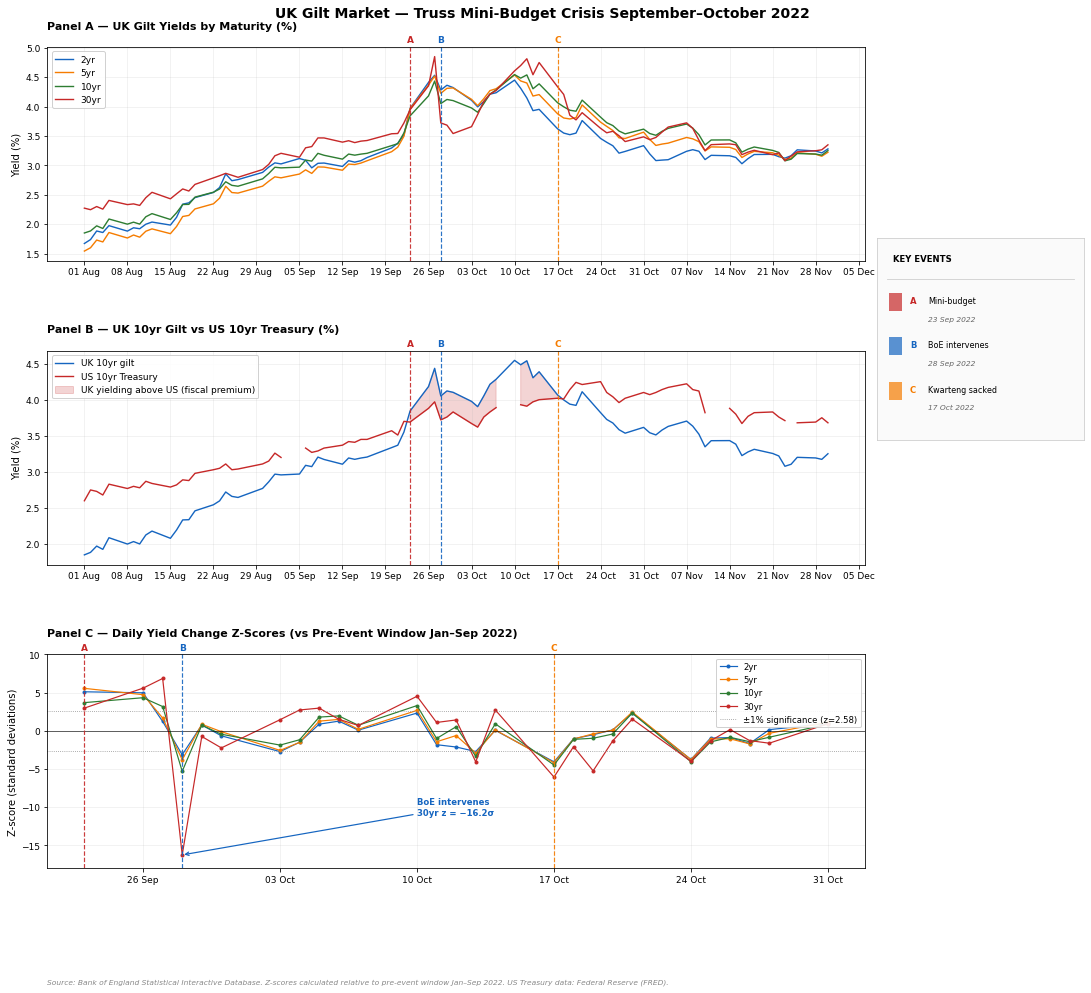

Chart 6 saved.


In [14]:
# ============================================================
# CHART 6 — TRUSS MINI-BUDGET EVENT STUDY — FIXED
# ============================================================

PRE_START     = pd.Timestamp('2022-01-03')
PRE_END       = pd.Timestamp('2022-09-22')
EVENT_DATE    = pd.Timestamp('2022-09-23')
BOE_INTERVENE = pd.Timestamp('2022-09-28')
KWARTENG_SACK = pd.Timestamp('2022-10-17')
CRISIS_END    = pd.Timestamp('2022-10-31')

gilts_changes = gilts_nominal.diff()
pre_window    = gilts_changes.loc[PRE_START:PRE_END]
pre_stats     = pd.DataFrame({
    'mean': pre_window.mean(),
    'std':  pre_window.std(),
})

maturities   = ['uk_2yr', 'uk_5yr', 'uk_10yr', 'uk_30yr']
event_window = gilts_changes.loc[EVENT_DATE:CRISIS_END]

zscore_records = []
for date, row in event_window.iterrows():
    day = {'date': date}
    for col in maturities:
        change  = row[col]
        z_score = ((change - pre_stats.loc[col, 'mean']) /
                   pre_stats.loc[col, 'std'])
        day[f'z_{col.replace("uk_", "")}'] = z_score
    zscore_records.append(day)
zscore_df = pd.DataFrame(zscore_records).set_index('date')

plot_start = pd.Timestamp('2022-08-01')
plot_end   = pd.Timestamp('2022-11-30')
gilts_zoom = gilts_nominal.loc[plot_start:plot_end]
us_zoom    = us_treasuries.loc[plot_start:plot_end]
us_aligned = us_zoom['us_10yr'].reindex(gilts_zoom.index, method='ffill')

# Use letter system for events
key_events = {
    'A': ('Mini-budget',     EVENT_DATE,    COLORS['negative']),
    'B': ('BoE intervenes',  BOE_INTERVENE, COLORS['uk']),
    'C': ('Kwarteng sacked', KWARTENG_SACK, COLORS['breakeven']),
}

mat_colors_truss = {
    'uk_2yr':  COLORS['uk_2yr'],
    'uk_5yr':  '#F57C00',
    'uk_10yr': '#2E7D32',
    'uk_30yr': COLORS['negative'],
}

fig, axes = plt.subplots(3, 1, figsize=(16, 14))
fig.suptitle('UK Gilt Market — Truss Mini-Budget Crisis '
             'September–October 2022',
             fontsize=14, fontweight='bold', y=0.98)
fig.subplots_adjust(hspace=0.42, top=0.94, right=0.78, left=0.07)

# --- PANEL A: yield levels ---
ax1 = axes[0]
for col, color in mat_colors_truss.items():
    ax1.plot(gilts_zoom.index.to_pydatetime(),
             gilts_zoom[col].values,
             color=color, linewidth=1.4,
             label=col.replace('uk_', ''))

for letter, (label, date, color) in key_events.items():
    ax1.axvline(x=date, color=color, linestyle='--',
                linewidth=1.2, alpha=0.9)
    ax1.text(date, 1.01, letter, fontsize=9, ha='center',
             va='bottom', color=color, fontweight='bold',
             transform=ax1.get_xaxis_transform())

ax1.set_title('Panel A — UK Gilt Yields by Maturity (%)',
              loc='left', pad=18)
ax1.set_ylabel('Yield (%)')
ax1.legend(loc='upper left', framealpha=0.9)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax1.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=0)

# --- PANEL B: UK vs US ---
ax2 = axes[1]
ax2.plot(gilts_zoom.index.to_pydatetime(),
         gilts_zoom['uk_10yr'].values,
         color=COLORS['uk'], linewidth=1.4, label='UK 10yr gilt')
ax2.plot(gilts_zoom.index.to_pydatetime(),
         us_aligned.values,
         color=COLORS['us'], linewidth=1.4, label='US 10yr Treasury')
ax2.fill_between(gilts_zoom.index.to_pydatetime(),
                 gilts_zoom['uk_10yr'].values,
                 us_aligned.values,
                 where=gilts_zoom['uk_10yr'].values > us_aligned.values,
                 alpha=0.20, color=COLORS['negative'],
                 label='UK yielding above US (fiscal premium)')

for letter, (label, date, color) in key_events.items():
    ax2.axvline(x=date, color=color, linestyle='--',
                linewidth=1.2, alpha=0.9)
    ax2.text(date, 1.01, letter, fontsize=9, ha='center',
             va='bottom', color=color, fontweight='bold',
             transform=ax2.get_xaxis_transform())

ax2.set_title('Panel B — UK 10yr Gilt vs US 10yr Treasury (%)',
              loc='left', pad=18)
ax2.set_ylabel('Yield (%)')
ax2.legend(loc='upper left', framealpha=0.9)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax2.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=0)

# --- PANEL C: z-scores ---
ax3 = axes[2]
zscore_cols = {
    'z_2yr':  COLORS['uk_2yr'],
    'z_5yr':  '#F57C00',
    'z_10yr': '#2E7D32',
    'z_30yr': COLORS['negative'],
}
for col, color in zscore_cols.items():
    ax3.plot(zscore_df.index.to_pydatetime(),
             zscore_df[col].values,
             color=color, linewidth=1.2,
             marker='o', markersize=3,
             label=col.replace('z_', ''))

ax3.axhline(y=0,     color='black', linewidth=0.6)
ax3.axhline(y=2.58,  color='#888888', linewidth=0.8,
            linestyle=':', label='±1% significance (z=2.58)')
ax3.axhline(y=-2.58, color='#888888', linewidth=0.8,
            linestyle=':')

for letter, (label, date, color) in key_events.items():
    ax3.axvline(x=date, color=color, linestyle='--',
                linewidth=1.2, alpha=0.9)
    ax3.text(date, 1.01, letter, fontsize=9, ha='center',
             va='bottom', color=color, fontweight='bold',
             transform=ax3.get_xaxis_transform())

# Annotate BoE intervention
boe_idx = zscore_df.index.get_indexer(
    [BOE_INTERVENE], method='nearest')[0]
ax3.annotate('BoE intervenes\n30yr z = −16.2σ',
             xy=(zscore_df.index[boe_idx].to_pydatetime(),
                 zscore_df['z_30yr'].iloc[boe_idx]),
             xytext=(pd.Timestamp('2022-10-10'), -11),
             fontsize=8.5, color=COLORS['uk'], fontweight='bold',
             arrowprops=dict(arrowstyle='->', color=COLORS['uk'],
                            lw=1.2))

ax3.set_title('Panel C — Daily Yield Change Z-Scores '
              '(vs Pre-Event Window Jan–Sep 2022)',
              loc='left', pad=18)
ax3.set_ylabel('Z-score (standard deviations)')
ax3.set_ylim(-18, 10)
ax3.legend(loc='upper right', framealpha=0.9, fontsize=8.5)
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax3.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))
plt.setp(ax3.xaxis.get_majorticklabels(), rotation=0)

# Key events legend box
ax_leg = fig.add_axes([0.79, 0.55, 0.18, 0.20])
ax_leg.set_xticks([])
ax_leg.set_yticks([])
ax_leg.set_xlim(0, 1)
ax_leg.set_ylim(0, 1)
for spine in ax_leg.spines.values():
    spine.set_edgecolor('#cccccc')
    spine.set_linewidth(0.8)
ax_leg.set_facecolor('#fafafa')

ax_leg.text(0.08, 0.92, 'KEY EVENTS',
            transform=ax_leg.transAxes,
            fontsize=8.5, fontweight='bold', va='top')
ax_leg.plot([0.05, 0.95], [0.80, 0.80], color='#cccccc',
            linewidth=0.8, transform=ax_leg.transAxes)

leg_entries = [
    ('A', 'Mini-budget',     '23 Sep 2022', COLORS['negative']),
    ('B', 'BoE intervenes',  '28 Sep 2022', COLORS['uk']),
    ('C', 'Kwarteng sacked', '17 Oct 2022', COLORS['breakeven']),
]
for i, (letter, desc, date, color) in enumerate(leg_entries):
    y = 0.68 - i * 0.22
    ax_leg.add_patch(plt.Rectangle(
        (0.06, y-0.04), 0.06, 0.09,
        transform=ax_leg.transAxes,
        facecolor=color, alpha=0.7, edgecolor='none'))
    ax_leg.text(0.16, y+0.01, letter, transform=ax_leg.transAxes,
                fontsize=8.5, fontweight='bold', va='center',
                color=color)
    ax_leg.text(0.25, y+0.01, desc, transform=ax_leg.transAxes,
                fontsize=8, va='center')
    ax_leg.text(0.25, y-0.08, date, transform=ax_leg.transAxes,
                fontsize=7.5, va='center', color='#666666',
                style='italic')

fig.text(0.07, 0.01,
         SOURCE_BOE + ' Z-scores calculated relative to pre-event '
         'window Jan–Sep 2022. US Treasury data: Federal Reserve (FRED).',
         fontsize=7.5, color='#888888', style='italic')

plt.savefig('outputs/charts/p06_truss_event_study.png')
plt.show()
print("Chart 6 saved.")